# Check age proportions in SSNAP data

Check the derived age-admissions coefficients by using them to recalculate the admissions numbers.

__Inputs:__
+ coefficients for "probability of stroke given age band" derived from the SSNAP data.
+ MSOA-level deprivation quantile and number of people in each age band.

__Results:__
+ Image: calculated vs. observed admission numbers for all MSOA
+ Image: calculated vs. observed admission numbers for all MSOA, split into one panel per deprivation band.


## Code setup

In [1]:
import polars as pl
import os
import numpy as np
import matplotlib.pyplot as plt

## Load data

HES data:

In [2]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

## Load SSNAP-derived probability coefficients:

In [3]:
df_pop_admissions = pl.read_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

## Check results: recalculate admissions

Calculate from SSNAP coefficients:

In [4]:
admission_props_annual = df_pop_admissions['prob_stroke_given_age'].to_numpy()

admission_props_annual

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

In [5]:
admissions_snap_props = sum([
    admission_props_annual[0] * df_stats['age_less65'],
    admission_props_annual[1] * df_stats['age_65'],
    admission_props_annual[2] * df_stats['age_70'],
    admission_props_annual[3] * df_stats['age_75'],
    admission_props_annual[4] * df_stats['age_over80'],
])
df_stats = df_stats.with_columns(pl.Series('admissions_from_ssnap_props', admissions_snap_props))

In [6]:
df_stats['admissions', 'admissions_from_ssnap_props']

admissions,admissions_from_ssnap_props
f64,f64
14.333333,14.423034
7.333333,13.377178
9.333333,12.579268
21.0,16.660679
13.666667,15.765181
…,…
14.333333,13.032092
12.666667,11.970012
16.333333,16.405731


## R-squared

Calculate r-squared metric:

In [7]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y_mean = y.mean()
    ss_res = ((yhat - y)**2.0).sum()
    ss_tot = ((y - y_mean)**2.0).sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

In [8]:
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

In [9]:
dict_r2 = {}

# R-squared for all points:
dict_r2['r2_all'] = np.round(calculate_rsquared(df_stats['admissions'], df_stats['admissions_from_ssnap_props']), 5)

# Separate r-squared for each deprivation quantile:
for q in qmin_list:
    qstr = str(round(q, 1)).replace('.', '')
    df_here = df_stats.filter(df_stats['depriv_quantile_min'] == q)

    r2_q = calculate_rsquared(df_here['admissions'], df_here['admissions_from_ssnap_props'])
    dict_r2[f'r2_q{qstr}'] = np.round(r2_q, 5)

In [10]:
dict_r2

{'r2_all': 0.47253,
 'r2_q00': 0.17179,
 'r2_q02': 0.52766,
 'r2_q04': 0.63211,
 'r2_q06': 0.55682,
 'r2_q08': 0.41202}

### Scatter results

In [11]:
dict_labels = dict(zip(qmin_list, ['0% to 20% (most deprived)', '20% to 40%', '40% to 60%', '60% to 80%', '80% to 100% (least deprived)']))

In [12]:
zmax = max([df_stats['admissions'].max(), max(df_stats['admissions_from_ssnap_props'])])
zmin = min([df_stats['admissions'].min(), min(df_stats['admissions_from_ssnap_props'])])

colours = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, len(qmin_list)))

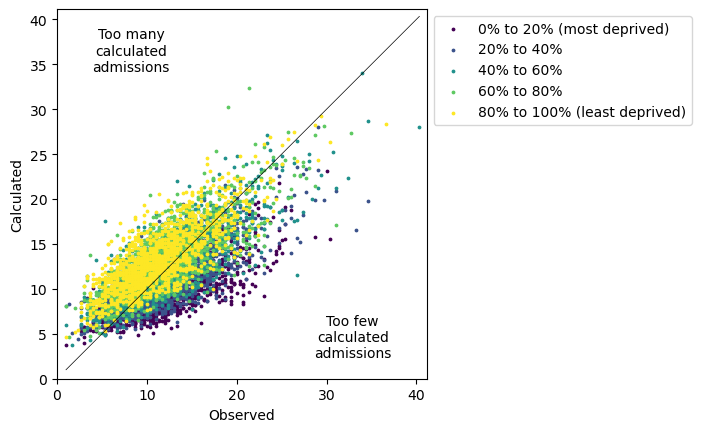

In [13]:
fig, ax = plt.subplots()
# Equality line:
ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5)

# Draw each quantile's data in turn:
for q, qmin in enumerate(qmin_list):
    df_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    ax.scatter(df_here['admissions'], df_here['admissions_from_ssnap_props'], s=3, color=colours[q], label=dict_labels[qmin])

# Labels:
ax.set_xlabel('Observed')
ax.set_ylabel('Calculated')
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
# Annotate which parts of the graph mean too high/low admissions:
ax.annotate('Too many\ncalculated\nadmissions', xy=(0.2, 0.95), ha='center', va='top', xycoords='axes fraction')
ax.annotate('Too few\ncalculated\nadmissions', xy=(0.8, 0.05), ha='center', va='bottom', xycoords='axes fraction')
# Sizing:
ax.set_xlim(0.0, zmax*1.02)
ax.set_ylim(0.0, zmax*1.02)
ax.set_aspect('equal')
# Save:
plt.savefig('./images/scatter_admissions_from_ssnap_coeffs.png', bbox_inches='tight')
plt.show()

Admissions are under-predicted for lowest quantile (most deprived) and over-predicted for highest quantile (least deprived).

Make a similar figure with the same data but each deprivation quantile on its own axis:

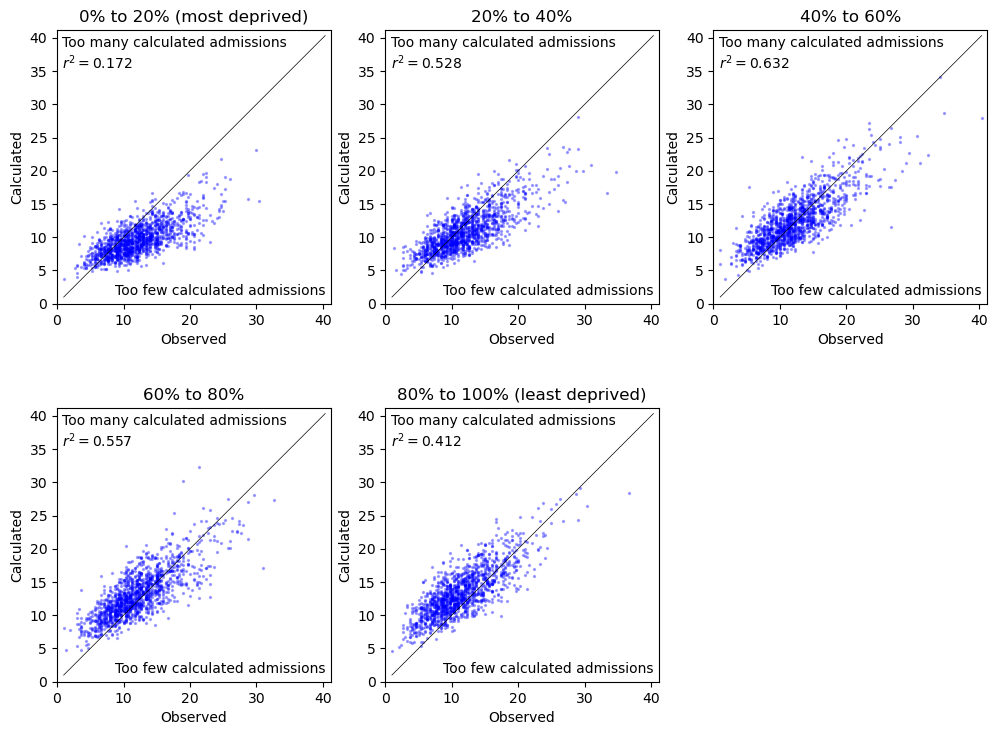

In [14]:
ncols=3
nrows=2
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 9))

# Draw each quantile's data in turn:
for q, qmin in enumerate(qmin_list):
    ax = axs[q // ncols, q % ncols]
    # Equality line:
    ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5)
    
    df_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    ax.scatter(
        df_here['admissions'],
        df_here['admissions_from_ssnap_props'],
        s=2,
        # color=colours[q],
        color='b',
        alpha=0.3
    )
    
    # Labels:
    ax.set_xlabel('Observed')
    ax.set_ylabel('Calculated')
    ax.set_title(dict_labels[qmin])
    # Annotate r-squared value:
    r2_key = f'r2_q{qmin:.1f}'.replace('.', '')
    r_str = r'$r^2=$' + f"{dict_r2[r2_key]:.3f}"
    # ax.annotate(, xy=(0.05, 0.85), ha='left', va='top', xycoords='axes fraction')
    # Annotate which parts of the graph mean too high/low admissions:
    ax.annotate('Too many calculated admissions\n'+r_str, xy=(0.02, 0.98), ha='left', va='top', xycoords='axes fraction')
    ax.annotate('Too few calculated admissions', xy=(0.98, 0.02), ha='right', va='bottom', xycoords='axes fraction')
    # Sizing:
    ax.set_xlim(0.0, zmax*1.02)
    ax.set_ylim(0.0, zmax*1.02)
    ax.set_aspect('equal')

axs[-1, -1].set_visible(False)
# Save:
plt.savefig('./images/scatter_admissions_from_ssnap_coeffs_separate.png', bbox_inches='tight')
plt.show()